<a href="https://colab.research.google.com/github/tmq24/Digital-Image-Analysis-and-Processing/blob/main/CLAHE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import cv2 as cv
from matplotlib import pyplot as plt
import os
import gdown

In [ ]:
gdown.download('https://drive.google.com/uc?export=download&id=1orE8pSgZStrfhnRbymZGucnLi7Y8Sw-B', 'z5963720541101_1a12c141c40a5d7c35ad6f357c311758.jpg', quiet=False)
gdown.download('https://drive.google.com/uc?export=download&id=1FBC0NESiAJNkWsf0pY8hKCkb40HCUwjp', 'king-edward-memorial.jpg', quiet=False)
gdown.download('https://drive.google.com/uc?export=download&id=1wYsLRWkvj-KgXes3LWHwQCx8MZjC4Fjs', 'KarlMax.jpg', quiet=False)


Downloading...
From: https://drive.google.com/uc?export=download&id=1orE8pSgZStrfhnRbymZGucnLi7Y8Sw-B
To: /content/z5963720541101_1a12c141c40a5d7c35ad6f357c311758.jpg
100%|██████████| 34.8k/34.8k [00:00<00:00, 36.5MB/s]
Downloading...
From: https://drive.google.com/uc?export=download&id=1FBC0NESiAJNkWsf0pY8hKCkb40HCUwjp
To: /content/king-edward-memorial.jpg
100%|██████████| 12.0k/12.0k [00:00<00:00, 21.1MB/s]
Downloading...
From: https://drive.google.com/uc?export=download&id=1wYsLRWkvj-KgXes3LWHwQCx8MZjC4Fjs
To: /content/KarlMax.jpg
100%|██████████| 163k/163k [00:00<00:00, 64.0MB/s]


'KarlMax.jpg'

In [ ]:
fil_path = '/content'  # Base directory path for image files
imgKarlMax = 'KarlMax.jpg'  # Filename of the Karl Marx image
imgKing = 'king-edward-memorial.jpg'  # Filename of the King Edward Memorial image
imgTsukuba_l = 'z5963720541101_1a12c141c40a5d7c35ad6f357c311758.jpg'  # Filename of the Tsukuba image

# Generate full file paths for the images by combining the base path with each filename
imgKarlMax_path = os.path.join(fil_path, imgKarlMax)  # Full path for Karl Marx image
imgKing_path = os.path.join(fil_path, imgKing)  # Full path for King Edward Memorial image
imgTsukuba_l_path = os.path.join(fil_path, imgTsukuba_l)  # Full path for Tsukuba image

# Find Histogram

Now we have an idea on what is histogram, we can look into how to find this. Both OpenCV and Numpy come with in-built function for this. Before using those functions, we need to understand some terminologies related with histograms.

- **BINS**: The above histogram shows the number of pixels for every pixel value, i.e. from 0 to 255. i.e., you need 256 values to show the above histogram. But consider, what if you need not find the number of pixels for all pixel values separately, but number of pixels in an interval of pixel values? Say for example, you need to find the number of pixels lying between 0 to 15, then 16 to 31, ..., 240 to 255. You will need only 16 values to represent the histogram. And that is what is shown in example given in OpenCV Tutorials on histograms.

So what you do is simply split the whole histogram to 16 sub-parts and value of each sub-part is the sum of all pixel count in it. This each sub-part is called "BIN". In first case, number of bins were 256 (one for each pixel), while in second case, it is only 16. BINS is represented by the term `histSize` in OpenCV docs.

- **DIMS**: It is the number of parameters for which we collect the data. In this case, we collect data regarding only one thing, intensity value. So here it is 1.

- **RANGE**: It is the range of intensity values you want to measure. Normally, it is [0,255], i.e., all intensity values.

## 1. Histogram Calculation in OpenCV

So now we use `cv.calcHist()` function to find the histogram. Let's familiarize with the function and its parameters:

```python
cv.calcHist(images, channels, mask, histSize, ranges[, hist[, accumulate]])
```

-images : it is the source image of type uint8 or float32. it should be given in square brackets, ie, "[img]".

-channels : it is also given in square brackets. It is the index of channel for which we calculate histogram. For example, if input is grayscale image, its value is [0]. For color image, you can pass [0], [1] or [2] to calculate histogram of blue, green or red channel respectively.

-mask : mask image. To find histogram of full image, it is given as "None". But if you want to find histogram of particular region of image, you have to create a mask image for that and give it as mask. (I will show an example later.)

-histSize : this represents our BIN count. Need to be given in square brackets. For full scale, we pass [256].

-ranges : this is our RANGE. Normally, it is [0,256].

So let's start with a sample image. Simply load an image in grayscale mode and find its full histogram.

In [ ]:
# Check if the file exists before reading
assert os.path.exists(imgKarlMax_path), f"File {imgKarlMax} does not exist"

# Read KarlMax image in grayscale
imgKarlMax = cv.imread(imgKarlMax_path, cv.IMREAD_GRAYSCALE)
assert imgKarlMax is not None, f"File {imgKarlMax} could not be read"

# Calculate the histogram of the image
hist = cv.calcHist([imgKarlMax], [0], None, [256], [0, 255])

hist is a 256x1 array, each value corresponds to number of pixels in that image with its corresponding pixel value.

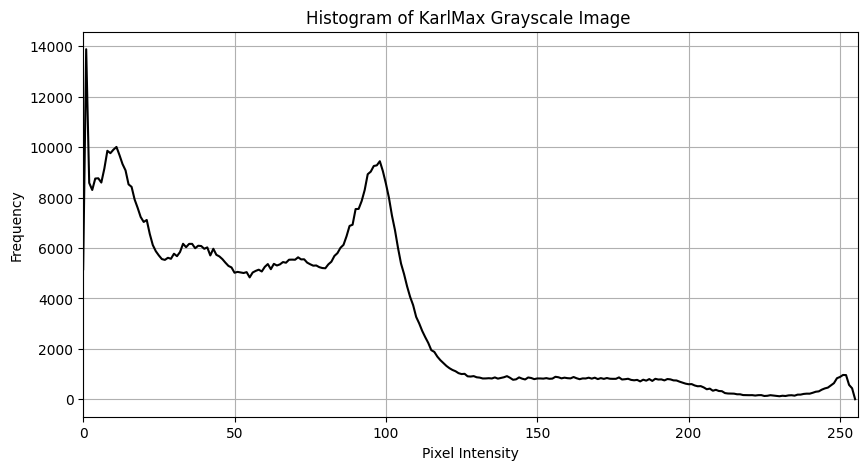

In [ ]:
# Plot the histogram
plt.figure(figsize=(10, 5))
plt.plot(hist, color='black')
plt.title('Histogram of KarlMax Grayscale Image ')
plt.xlabel('Pixel Intensity')
plt.ylabel('Frequency')
plt.xlim([0, 256])
plt.grid()
plt.show()

## 2. Histogram Calculation in Numpy

Numpy also provides you a function, `np.histogram()`. So instead of `calcHist()` function, you can try the line below:

```python
hist, bins = np.histogram(img.flatten(), 256, [0, 255])
```
hist is the same as we calculated before. But bins will have 257 elements, because Numpy calculates bins as 0-0.99, 1-1.99, 2-2.99, etc. So the final range would be 255-255.99. To represent that, they also add 256 at the end of bins. But we don’t need that 256. Upto 255 is sufficient.

**Plotting Histograms**

There are two ways for this:

Short Way: use Matplotlib plotting functions

Long Way: use OpenCV drawing functions

**1. Using Matplotlib**

Matplotlib comes with a histogram plotting function : matplotlib.pyplot.hist()

It directly finds the histogram and plot it. You need not use calcHist() or np.histogram() function to find the histogram. See the code below:

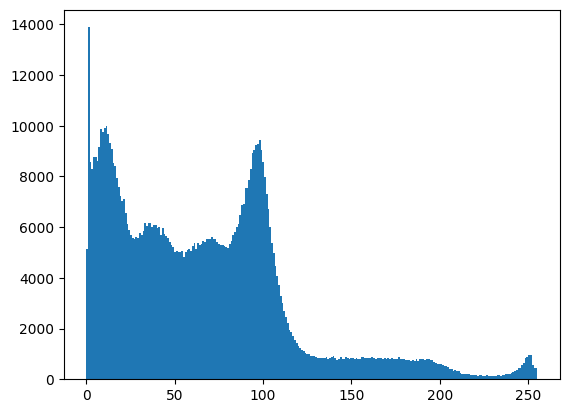

In [ ]:
# Load the image at 'imgKarlMax_path' in grayscale mode
imgKarlMax_GRAYSCALE = cv.imread(imgKarlMax_path, cv.IMREAD_GRAYSCALE)

# Verify that the image has been loaded successfully; if not, raise an error message
assert imgKarlMax_GRAYSCALE is not None, "File could not be read; check with os.path.exists()"

# Display the histogram of pixel intensities in the grayscale image
plt.hist(imgKarlMax_GRAYSCALE.ravel(), 256, [0, 255])
plt.show()


Or you can use normal plot of matplotlib, which would be good for BGR plot. For that, you need to find the histogram data first. Try below code:

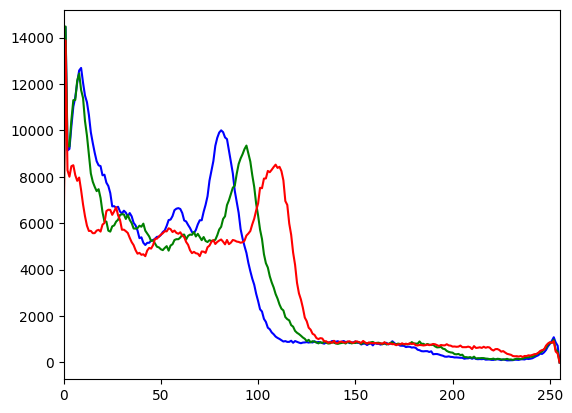

In [ ]:
# Load the color image at 'imgKarlMax_path'
imgKarlMax = cv.imread(imgKarlMax_path)

# Verify that the image has been loaded successfully; if not, raise an error message
assert imgKarlMax is not None, "File could not be read; check with os.path.exists()"

# Define color channels for plotting ('b' for blue, 'g' for green, and 'r' for red)
color = ('b', 'g', 'r')

# Iterate over each color channel (blue, green, red) to calculate and plot its histogram
for i, col in enumerate(color):
    histr = cv.calcHist([imgKarlMax], [i], None, [256], [0, 255])  # Calculate histogram for each color channel
    plt.plot(histr, color=col)  # Plot histogram for the current color channel
    plt.xlim([0, 255])  # Set the x-axis range for pixel intensities

# Display the histograms of all three color channels
plt.show()


# Histogram Equalization

Consider an image whose pixel values are confined to some specific range of values only. For eg, brighter image will have all pixels confined to high values. But a good image will have pixels from all regions of the image. So you need to stretch this histogram to either ends (as given in below image, from wikipedia) and that is what Histogram Equalization does (in simple words). This normally improves the contrast of the image.

## Histogram Equalization in Numpy

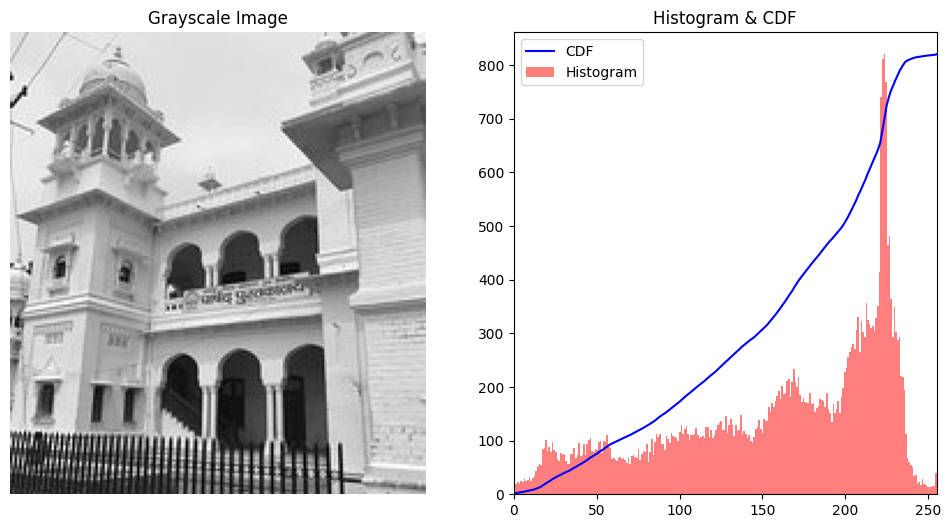

In [ ]:
# Load the grayscale image at 'imgKing_path'
img = cv.imread(imgKing_path, cv.IMREAD_GRAYSCALE)

# Verify that the image has been loaded successfully; if not, raise an error message
assert img is not None, "File could not be read; check with os.path.exists()"

# Calculate the histogram and cumulative distribution function (CDF)
hist, bins = np.histogram(img.flatten(), 256, [0, 255])  # Compute histogram with 256 bins over the range [0, 255]
cdf = hist.cumsum()  # Compute cumulative sum to obtain the CDF
cdf_normalized = cdf * float(hist.max()) / cdf.max()  # Normalize CDF for visualization

# Set up the plot figure with a specified size
plt.figure(figsize=(12, 6))

# Plot the grayscale image
plt.subplot(1, 2, 1)
plt.imshow(img, cmap='gray')  # Display image in grayscale
plt.title("Grayscale Image")  # Set title
plt.axis('off')  # Hide axes

# Plot the histogram and normalized CDF
plt.subplot(1, 2, 2)
plt.plot(cdf_normalized, color='b')  # Plot CDF in blue
plt.hist(img.flatten(), 256, [0, 255], color='r', alpha=0.5)  # Plot histogram in red with some transparency
plt.xlim([0, 255])  # Set x-axis range for pixel intensities
plt.legend(('CDF', 'Histogram'), loc='upper left')  # Add a legend
plt.title("Histogram & CDF")  # Set title

# Display the plots
plt.show()


You can see histogram lies in brighter region. We need the full spectrum. For that, we need a transformation function which maps the input pixels in brighter region to output pixels in full region. That is what histogram equalization does.

Now we find the minimum histogram value (excluding 0) and apply the histogram equalization equation as given in wiki page. But I have used here, the masked array concept array from Numpy. For masked array, all operations are performed on non-masked elements. You can read more about it from Numpy docs on masked arrays.

In [ ]:
# Mask all zero values in the CDF to avoid issues with division by zero
cdf_m = np.ma.masked_equal(cdf, 0)

# Normalize the CDF values to fit the range [0, 255]
# Subtract the minimum CDF value, multiply by 255, then divide by the range of CDF values (max - min)
cdf_m = (cdf_m - cdf_m.min()) * 255 / (cdf_m.max() - cdf_m.min())

# Replace masked elements (previously 0 in the original CDF) with 0, and cast to uint8 for image compatibility
cdf = np.ma.filled(cdf_m, 0).astype('uint8')


Now we have the look-up table that gives us the information on what is the output pixel value for every input pixel value. So we just apply the transform.



In [ ]:
img2 = cdf[img]

Now we calculate its histogram and cdf as before and result looks like below :



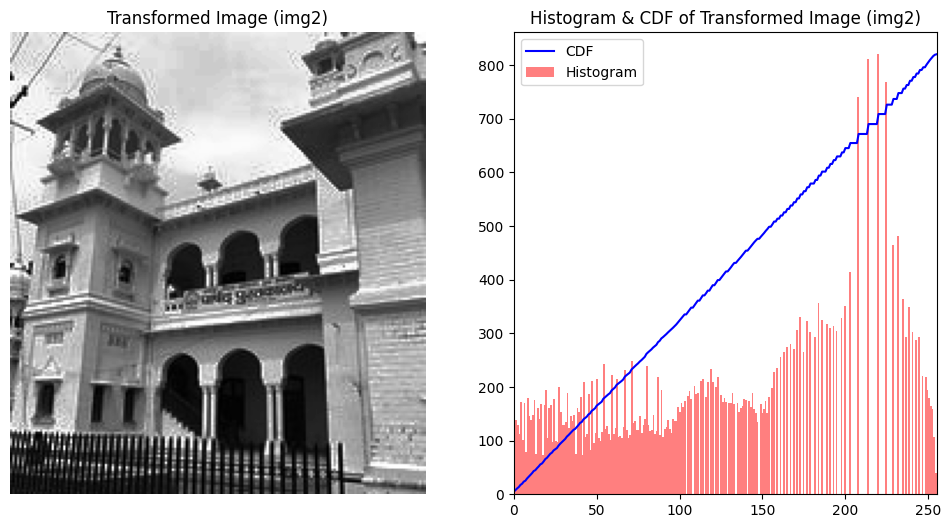

In [ ]:
# Calculate the histogram and cumulative distribution function (CDF) of img2
hist, bins = np.histogram(img2.flatten(), 256, [0, 255])  # Compute histogram with 256 bins over range [0, 255]
cdf = hist.cumsum()  # Compute cumulative sum to get the CDF
cdf_normalized = cdf * float(hist.max()) / cdf.max()  # Normalize the CDF for visualization

# Set up the plot figure with a specified size
plt.figure(figsize=(12, 6))

# Display img2 as a grayscale image
plt.subplot(1, 2, 1)
plt.imshow(img2, cmap='gray')  # Display the transformed image in grayscale
plt.title("Transformed Image (img2)")  # Set title
plt.axis('off')  # Hide axes

# Display the histogram and normalized CDF of img2
plt.subplot(1, 2, 2)
plt.plot(cdf_normalized, color='b')  # Plot normalized CDF in blue
plt.hist(img2.flatten(), 256, [0, 255], color='r', alpha=0.5)  # Plot histogram in red with some transparency
plt.xlim([0, 255])  # Set x-axis range for pixel intensities
plt.legend(('CDF', 'Histogram'), loc='upper left')  # Add a legend for clarity
plt.title("Histogram & CDF of Transformed Image (img2)")  # Set title

# Show the plots
plt.show()


In [ ]:
cv.imwrite('imgking1.png',img)
cv.imwrite('imgking2.png',img2)

True

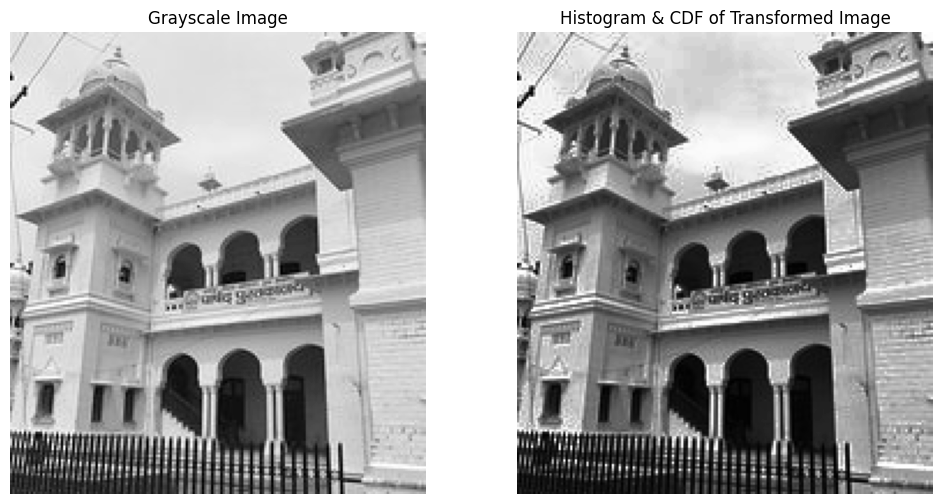

In [ ]:
# Set up the figure size for the subplots
plt.figure(figsize=(12, 6))

# Display the original grayscale image
plt.subplot(1, 2, 1)
plt.imshow(img, cmap='gray')  # Show 'img' in grayscale
plt.title("Grayscale Image")  # Set title for the original image
plt.axis('off')  # Hide axes

# Display the transformed grayscale image (img2)
plt.subplot(1, 2, 2)
plt.imshow(img2, cmap='gray')  # Show 'img2' in grayscale
plt.title("Histogram & CDF of Transformed Image")  # Set title for the transformed image
plt.axis('off')  # Hide axes

# Display the plots
plt.show()


## Histograms Equalization in OpenCV

OpenCV has a function to do this, cv.equalizeHist(). Its input is just grayscale image and output is our histogram equalized image.

Below is a simple code snippet showing its usage for same image we used

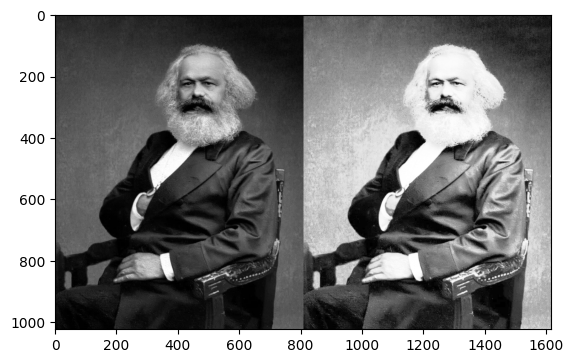

In [ ]:
# Load the grayscale image from 'imgKarlMax_path'
img = cv.imread(imgKarlMax_path, cv.IMREAD_GRAYSCALE)

# Verify that the image has been loaded successfully; if not, raise an error message
assert img is not None, "File could not be read; check with os.path.exists()"

# Apply histogram equalization to the grayscale image
equ = cv.equalizeHist(img)

# Stack the original and equalized images side-by-side for comparison
res = np.hstack((img, equ))  # Combine original (img) and equalized (equ) images horizontally

# Save the resulting stacked image as 'imgKarlMax_res.png'
cv.imwrite('imgKarlMax_res.png', res)

# Display the stacked image
plt.imshow(res, cmap="gray")  # Show 'res' as a grayscale image
plt.show()


# **Application of Mask**

We used cv.calcHist() to find the histogram of the full image. What if you want to find histograms of some regions of an image? Just create a mask image with white color on the region you want to find histogram and black otherwise. Then pass this as the mask.

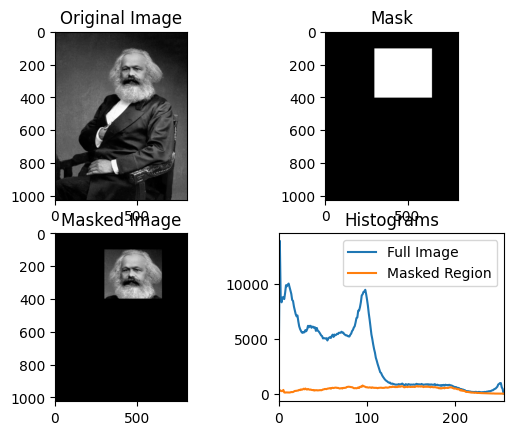

In [ ]:
# Load the grayscale image from 'imgKarlMax_path'
img = cv.imread(imgKarlMax_path, cv.IMREAD_GRAYSCALE)

# Verify that the image has been loaded successfully; if not, raise an error message
assert img is not None, "File could not be read; check with os.path.exists()"

# Create a mask with the same dimensions as the image, initialized to 0 (black)
mask = np.zeros(img.shape[:2], np.uint8)

# Define a rectangular region in the mask (from row 100 to 400, and column 300 to 650) and set it to 255 (white)
mask[100:400, 300:650] = 255

# Apply the mask to the image using a bitwise AND operation
masked_img = cv.bitwise_and(img, img, mask=mask)

# Calculate histogram of the full image (no mask) and the masked region only
hist_full = cv.calcHist([img], [0], None, [256], [0, 255])  # Histogram of full image
hist_mask = cv.calcHist([img], [0], mask, [256], [0, 255])  # Histogram of masked region only

# Set up subplots to display the images and histograms
plt.subplot(221), plt.imshow(img, 'gray')  # Original image
plt.title("Original Image")

plt.subplot(222), plt.imshow(mask, 'gray')  # Display the mask
plt.title("Mask")

plt.subplot(223), plt.imshow(masked_img, 'gray')  # Display the masked image
plt.title("Masked Image")

# Display histograms: full image histogram and masked region histogram
plt.subplot(224), plt.plot(hist_full, label='Full Image'), plt.plot(hist_mask, label='Masked Region')
plt.xlim([0, 256])  # Set x-axis range for pixel intensities
plt.legend()  # Add a legend to distinguish between histograms
plt.title("Histograms")

# Display all subplots
plt.show()


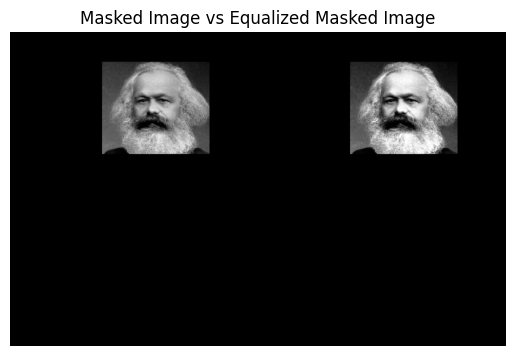

In [ ]:
# Apply histogram equalization to the masked image
equ = cv.equalizeHist(masked_img)

# Stack the original masked image and the equalized image side-by-side for comparison
res = np.hstack((masked_img, equ))  # Combine 'masked_img' and 'equ' horizontally

# Save the resulting stacked image as 'imgKarlMax_Maskres.png'
cv.imwrite('imgKarlMax_Maskres.png', res)

# Display the stacked image
plt.imshow(res, cmap="gray")  # Show the combined image in grayscale
plt.title("Masked Image vs Equalized Masked Image")  # Set title for clarity
plt.axis('off')  # Hide axes for a cleaner display

# Render the image
plt.show()


## CLAHE (Contrast Limited Adaptive Histogram Equalization)

The first histogram equalization we just saw, considers the global contrast of the image. In many cases, it is not a good idea. For example, below image shows an input image and its result after global histogram equalization.

It is true that the background contrast has improved after histogram equalization. But compare the face of statue in both images. We lost most of the information there due to over-brightness. It is because its histogram is not confined to a particular region as we saw in previous cases (Try to plot histogram of input image, you will get more intuition).



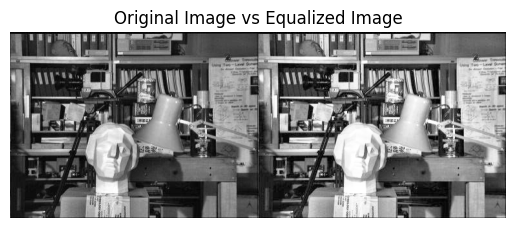

In [ ]:
# Load the grayscale image from 'imgTsukuba_l_path'
img = cv.imread(imgTsukuba_l_path, cv.IMREAD_GRAYSCALE)

# Verify that the image has been loaded successfully; if not, raise an error message
assert img is not None, "File could not be read; check with os.path.exists()"

# Apply histogram equalization to enhance contrast in the grayscale image
equ = cv.equalizeHist(img)

# Stack the original image and the equalized image side-by-side for comparison
res = np.hstack((img, equ))  # Combine the original image ('img') and the equalized image ('equ') horizontally

# Save the resulting stacked image as 'imgTsukuba_l_res.png'
cv.imwrite('imgTsukuba_l_res.png', res)

# Display the stacked image
plt.imshow(res, cmap="gray")  # Show the combined image in grayscale
plt.title("Original Image vs Equalized Image")  # Set title for clarity
plt.axis('off')  # Hide axes for a cleaner display

# Render the image
plt.show()


See the result and compare it with results above, especially the statue region



So to solve this problem, adaptive histogram equalization is used. In this, image is divided into small blocks called "tiles" (tileSize is 8x8 by default in OpenCV). Then each of these blocks are histogram equalized as usual. So in a small area, histogram would confine to a small region (unless there is noise). If noise is there, it will be amplified. To avoid this, contrast limiting is applied. If any histogram bin is above the specified contrast limit (by default 40 in OpenCV), those pixels are clipped and distributed uniformly to other bins before applying histogram equalization. After equalization, to remove artifacts in tile borders, bilinear interpolation is applied.

Below code snippet shows how to apply CLAHE in OpenCV:

In [ ]:
# Load the grayscale image from 'imgTsukuba_l_path'
img = cv.imread(imgTsukuba_l_path, cv.IMREAD_GRAYSCALE)

# Verify that the image has been loaded successfully; if not, raise an error message
assert img is not None, "File could not be read; check with os.path.exists()"

# Create a CLAHE (Contrast Limited Adaptive Histogram Equalization) object
# clipLimit: sets the threshold for contrast limiting
# tileGridSize: defines the number of tiles in the grid (here, an 8x8 grid)
clahe = cv.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))

# Apply the CLAHE to the grayscale image
cl1 = clahe.apply(img)

# Save the result of CLAHE applied image as 'clahe_2.jpg'
cv.imwrite('clahe_2.jpg', cl1)


True

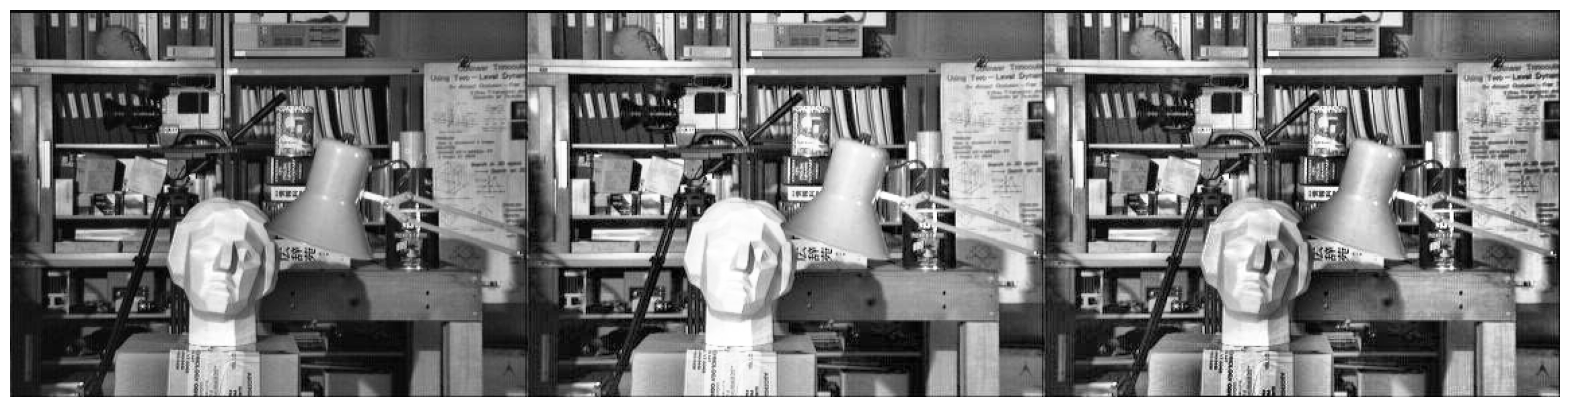

In [ ]:
# Stack the original image, the equalized image, and the CLAHE result side-by-side
res = np.hstack((img, equ, cl1))  # Combine 'img', 'equ', and 'cl1' horizontally

# Set the figure size for the display
plt.figure(figsize=(20, 20))  # Create a figure with a width and height of 20 inches

# Display the stacked image with a grayscale color map
plt.imshow(res, cmap="gray")  # Show the combined image in grayscale
plt.axis('off')  # Turn off axis ticks and labels for a cleaner look

# Render the image
plt.show()  # Display the figure with the stacked images


# **Exercise**


1. Choose an external image and fulfill all the requirements above.

2. Explain the concept of "BINS" and its role in creating an image histogram.

3. Why do we need to divide the histogram into "BINS"?

4. In the `cv.calcHist()` function, what do the `image`, `channel`, `mask`, `histSize`, and `range` parameters mean?

5. Based on the histogram of the image, what comments do you have about the image?

6. Draw a histogram of the image after equalization and compare it with the un-equalized image; what comments do you make?

7. Using your intuition when comparing the image after equalization with the original image, give your comments.

## 2. Explain the concept of "BINS" and its role in creating an image histogram.
- Định nghĩa Bins: Bins là các khoảng liên tiếp, không chồng lấn, phân chia phạm vi các giá trị cường độ pixel. Mỗi bin bao gồm một khoảng giá trị cường độ cụ thể.

- Vai trò trong Histogram: Bins là cấu trúc nền tảng của histogram. Bằng cách đếm số lượng pixel nằm trong phạm vi của mỗi bin, histogram cung cấp biểu diễn trực quan về phân bố cường độ của hình ảnh. Sự trực quan này giúp hiểu về độ tương phản, độ sáng và phân bố tông màu tổng thể của hình ảnh.

## 3. Why do we need to divide the histogram into "BINS"?
- Đơn giản hóa Dữ liệu: Các giá trị cường độ pixel liên tục được nhóm vào các bins, đơn giản hóa dữ liệu và làm cho việc phân tích trở nên dễ dàng hơn.

- Trực quan hóa: Bins cho phép tạo ra histogram biểu diễn trực quan tần suất phân bố cường độ pixel, làm nổi bật các vùng có mật độ cao và thấp.

- Phân tích và Xử lý: Việc chia thành bins hỗ trợ các tác vụ xử lý ảnh như tăng cường độ tương phản, phân ngưỡng và phân đoạn, bằng cách cung cấp thông tin chi tiết về phân bố cường độ.

## 4. In the cv.calcHist() function, what do the image, channel, mask, histSize, and range parameters mean?
- `images`: là hình ảnh nguồn có kiểu uint8 hoặc float32. Nó phải được đặt trong dấu ngoặc vuông "[img]".

- `channels` : Danh sách chỉ số của kênh cần sử dụng. Đây là chỉ số của kênh mà chúng ta tính toán histogram. Ví dụ, nếu đầu vào là grayscale image, giá trị của nó là [0]. Đối với hình ảnh màu, bạn có thể truyền [0], [1] hoặc [2] để tính histogram của blue, green or red channel tương ứng.

- `mask`: mask image. Để tìm histogram của toàn bộ ảnh, mặc định là "None". Nhưng nếu bạn muốn tìm histogram của vùng ảnh cụ thể, bạn phải tạo một mask image cho vùng đó và đưa nó vào như mask.

- `histSize`: Danh sách chỉ số số lượng bins cho histogram. Cần được đưa vào trong dấu ngoặc vuông. Đối với fullscale, truyền [256].

- `ranges`: Danh sách phạm vi giá trị cường độ cho các bins.  Thông thường, giá trị là [0, 256] cho hình ảnh 8-bit, bao phủ toàn bộ phạm vi giá trị pixel có thể có.

In [ ]:
import numpy as np
import cv2 as cv
from matplotlib import pyplot as plt
import os
import gdown

In [ ]:
url = 'https://drive.google.com/uc?id=1OfbOhVxYnm4XJ3kM-sRwC55DOuFCEw6I'
gdown.download(url, 'people.jpg', quiet=False)

Downloading...
From: https://drive.google.com/uc?id=1OfbOhVxYnm4XJ3kM-sRwC55DOuFCEw6I
To: /content/people.jpg
100%|██████████| 91.1k/91.1k [00:00<00:00, 36.4MB/s]


'people.jpg'

In [ ]:
fil_path = '/content'
imgPeople = 'people.jpg'

# Generate full file paths for the images by combining the base path with each filename
imgPeople_path = os.path.join(fil_path, imgPeople)

In [ ]:
# Check if the file exists before reading
assert os.path.exists(imgPeople_path), f"File {imgPeople} does not exist"

# Read KarlMax image in grayscale
imgPeople = cv.imread(imgPeople_path, cv.IMREAD_GRAYSCALE)
assert imgPeople is not None, f"File {imgPeople} could not be read"

# Find Histogram
## 1. Histogram Calculation in OpenCV

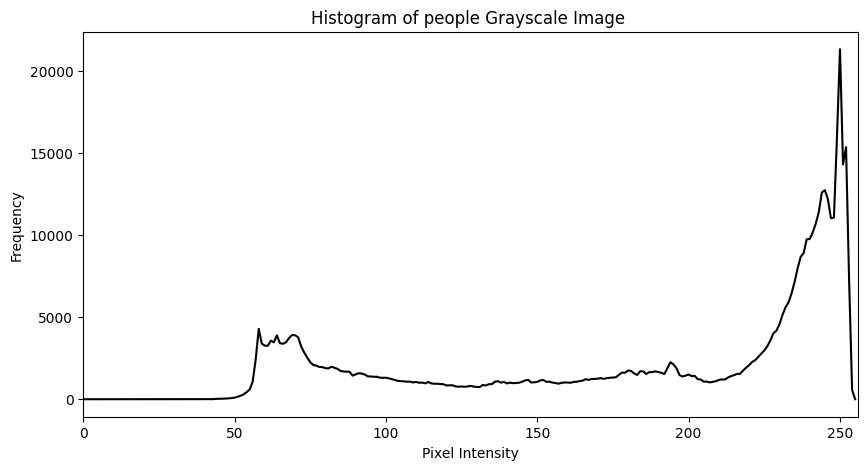

In [ ]:
# Calculate the histogram of the image
hist = cv.calcHist([imgPeople], [0], None, [256], [0, 255])

# Plot the histogram
plt.figure(figsize=(10, 5))
plt.plot(hist, color='black')
plt.title('Histogram of people Grayscale Image ')
plt.xlabel('Pixel Intensity')
plt.ylabel('Frequency')
plt.xlim([0, 256])
plt.show()

## 2. Use Matplotlib plotting functions

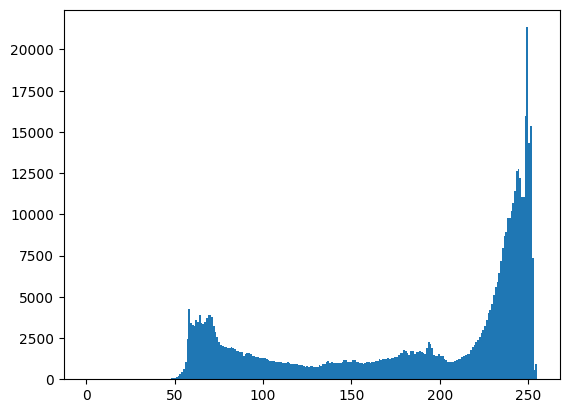

In [ ]:
plt.hist(imgPeople.ravel(), 256, [0, 255])
plt.show()

Or you can use normal plot of matplotlib, which would be good for BGR plot. For that, you need to find the histogram data first. Try below code:

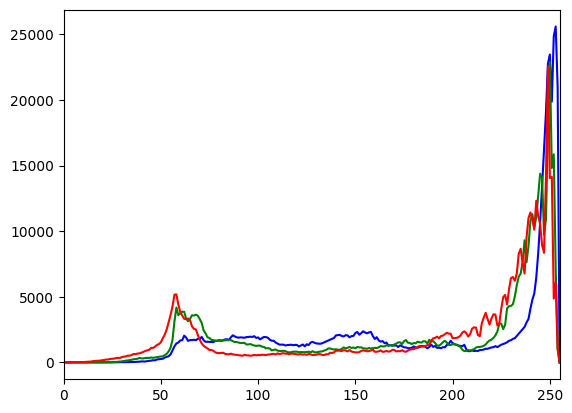

In [ ]:
# Load the color image at 'imgPeople_path'
imgPeople = cv.imread(imgPeople_path)

# Verify that the image has been loaded successfully; if not, raise an error message
assert imgPeople is not None, "File could not be read; check with os.path.exists()"

# Define color channels for plotting ('b' for blue, 'g' for green, and 'r' for red)
color = ('b', 'g', 'r')

# Iterate over each color channel (blue, green, red) to calculate and plot its histogram
for i, col in enumerate(color):
    histr = cv.calcHist([imgPeople], [i], None, [256], [0, 255])  # Calculate histogram for each color channel
    plt.plot(histr, color=col)  # Plot histogram for the current color channel
    plt.xlim([0, 255])  # Set the x-axis range for pixel intensities

# Display the histograms of all three color channels
plt.show()


# Histogram Equalization
## Histogram Equalization in Numpy

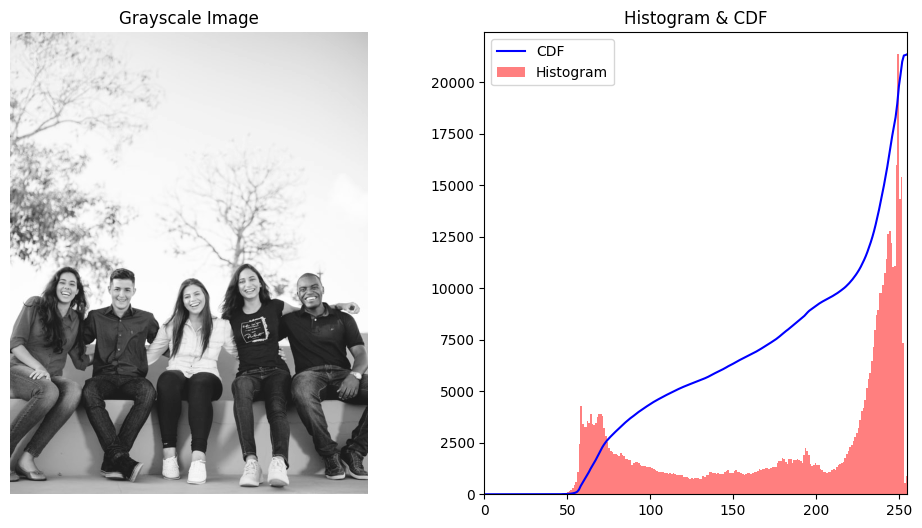

In [ ]:
# Load the grayscale image at 'imgKing_path'
img = cv.imread(imgPeople_path, cv.IMREAD_GRAYSCALE)

# Verify that the image has been loaded successfully; if not, raise an error message
assert img is not None, "File could not be read; check with os.path.exists()"

# Calculate the histogram and cumulative distribution function (CDF)
hist, bins = np.histogram(img.flatten(), 256, [0, 255])  # Compute histogram with 256 bins over the range [0, 255]
cdf = hist.cumsum()  # Compute cumulative sum to obtain the CDF
cdf_normalized = cdf * float(hist.max()) / cdf.max()  # Normalize CDF for visualization

# Set up the plot figure with a specified size
plt.figure(figsize=(12, 6))

# Plot the grayscale image
plt.subplot(1, 2, 1)
plt.imshow(img, cmap='gray')  # Display image in grayscale
plt.title("Grayscale Image")  # Set title
plt.axis('off')  # Hide axes

# Plot the histogram and normalized CDF
plt.subplot(1, 2, 2)
plt.plot(cdf_normalized, color='b')  # Plot CDF in blue
plt.hist(img.flatten(), 256, [0, 255], color='r', alpha=0.5)  # Plot histogram in red with some transparency
plt.xlim([0, 255])  # Set x-axis range for pixel intensities
plt.legend(('CDF', 'Histogram'), loc='upper left')  # Add a legend
plt.title("Histogram & CDF")  # Set title

# Display the plots
plt.show()


### **Nhận xét:**
- Histogram của ảnh cho thấy phân bố với hai đỉnh chính: một đỉnh nhỏ ở vùng tối-trung bình (khoảng 50-100) và một đỉnh rất cao ở vùng sáng (220-255). Đỉnh cao nhất xuất hiện ở khoảng giá trị 250, thể hiện số lượng lớn pixel ở vùng sáng, phản ánh khu vực nền trời và các phần sáng trong ảnh. Trong khi đó, vùng trung bình (100-200) có phân bố thấp và dao động nhẹ, chủ yếu thể hiện các chi tiết trung gian. Vùng tối-trung bình (50-100) có một đỉnh nhỏ, thể hiện các vùng tối vừa phải như quần áo và bóng, còn vùng tối (0-50) gần như không có pixel, cho thấy ảnh không có vùng quá tối.

- CDF cho thấy độ sáng tổng thể của hình ảnh: Đường CDF tăng nhanh ở cuối, cho thấy sự tập trung pixel ở vùng sáng. CDF không trải đều từ 0 đến 255, điều này làm rõ rằng hình ảnh có thể hưởng lợi từ việc cân bằng histogram để trải đều các mức độ sáng, giúp tăng cường chi tiết ở cả vùng sáng và tối.

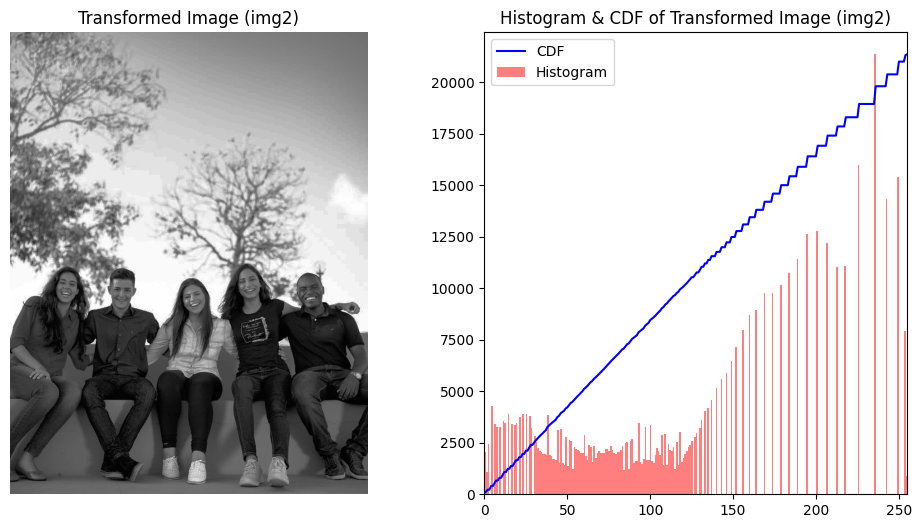

In [ ]:
# Mask all zero values in the CDF to avoid issues with division by zero
cdf_m = np.ma.masked_equal(cdf, 0)

# Normalize the CDF values to fit the range [0, 255]
# Subtract the minimum CDF value, multiply by 255, then divide by the range of CDF values (max - min)
cdf_m = (cdf_m - cdf_m.min()) * 255 / (cdf_m.max() - cdf_m.min())

# Replace masked elements (previously 0 in the original CDF) with 0, and cast to uint8 for image compatibility
cdf = np.ma.filled(cdf_m, 0).astype('uint8')

img2 = cdf[img]

# Calculate the histogram and cumulative distribution function (CDF) of img2
hist, bins = np.histogram(img2.flatten(), 256, [0, 255])  # Compute histogram with 256 bins over range [0, 255]
cdf = hist.cumsum()  # Compute cumulative sum to get the CDF
cdf_normalized = cdf * float(hist.max()) / cdf.max()  # Normalize the CDF for visualization

# Set up the plot figure with a specified size
plt.figure(figsize=(12, 6))

# Display img2 as a grayscale image
plt.subplot(1, 2, 1)
plt.imshow(img2, cmap='gray')  # Display the transformed image in grayscale
plt.title("Transformed Image (img2)")  # Set title
plt.axis('off')  # Hide axes

# Display the histogram and normalized CDF of img2
plt.subplot(1, 2, 2)
plt.plot(cdf_normalized, color='b')  # Plot normalized CDF in blue
plt.hist(img2.flatten(), 256, [0, 255], color='r', alpha=0.5)  # Plot histogram in red with some transparency
plt.xlim([0, 255])  # Set x-axis range for pixel intensities
plt.legend(('CDF', 'Histogram'), loc='upper left')  # Add a legend for clarity
plt.title("Histogram & CDF of Transformed Image (img2)")  # Set title

# Show the plots
plt.show()

### **Nhận xét:**
- So sánh ảnh:

Ảnh đã qua biến đổi có độ tương phản tốt hơn, giúp chi tiết trở nên rõ ràng hơn ở mọi vùng. Vùng tối và sáng đã được cân bằng tốt hơn, làm nổi bật các chi tiết như đường nét trên khuôn mặt và quần áo của người trong ảnh.

- Phân tích Histogram mới:

Histogram của ảnh sau biến đổi có sự thay đổi lớn so với ban đầu, với phân bố đều hơn trên toàn dải giá trị pixel. Hiện tượng tập trung quá nhiều ở vùng sáng không còn xuất hiện, và các cột trong histogram có độ cao tương đối đồng đều, cho thấy sự cân bằng trong phân bố sáng tối. Dù có sự biến đổi, histogram vẫn giữ được các thông tin quan trọng của ảnh.

- Phân tích CDF mới:

Đường CDF của ảnh biến đổi gần như là một đường thẳng và tăng đều từ 0 đến 255, cho thấy phân bố của các pixel đã đồng đều hơn. Độ dốc ổn định trên toàn dải cường độ phản ánh rằng độ tương phản của ảnh đã được cải thiện rõ rệt.

Nhìn chung, ảnh đã qua biến đổi có độ tương phản cân bằng tốt hơn, bảo toàn chi tiết ở cả vùng sáng và tối. Hiện tượng over-exposure ở phần nền trời đã được giảm bớt, giúp các khuôn mặt và quần áo trong ảnh có độ tương phản rõ ràng hơn, tạo cảm giác hài hòa và sắc nét hơn.

In [ ]:
cv.imwrite('imgPeople1.png',img)
cv.imwrite('imgPeople2.png',img2)

True

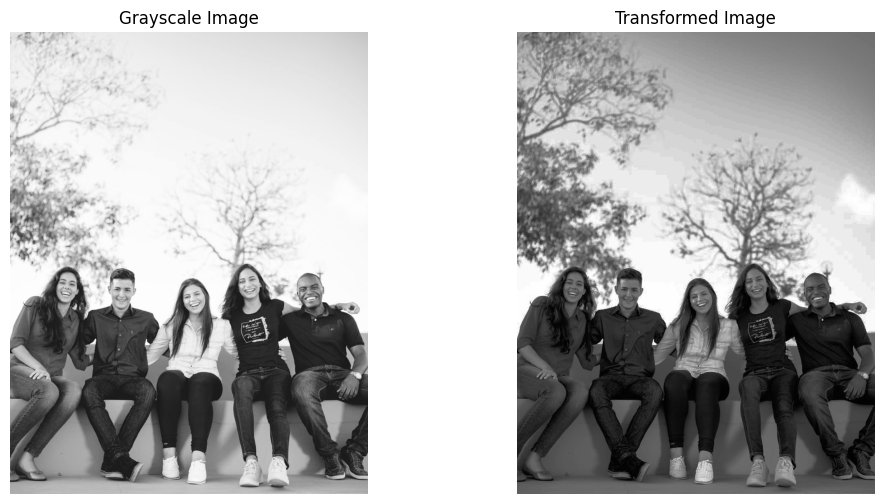

In [ ]:
# Set up the figure size for the subplots
plt.figure(figsize=(12, 6))

# Display the original grayscale image
plt.subplot(1, 2, 1)
plt.imshow(img, cmap='gray')  # Show 'img' in grayscale
plt.title("Grayscale Image")  # Set title for the original image
plt.axis('off')  # Hide axes

# Display the transformed grayscale image (img2)
plt.subplot(1, 2, 2)
plt.imshow(img2, cmap='gray')  # Show 'img2' in grayscale
plt.title("Transformed Image")  # Set title for the transformed image
plt.axis('off')  # Hide axes

# Display the plots
plt.show()


## Histograms Equalization in OpenCV

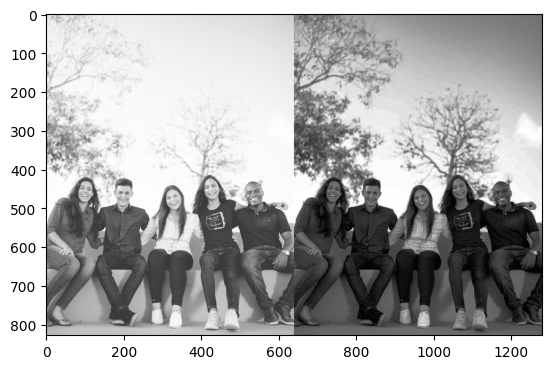

In [ ]:
# Load the grayscale image from 'imgPeople_path'
img3 = cv.imread(imgPeople_path, cv.IMREAD_GRAYSCALE)

# Verify that the image has been loaded successfully; if not, raise an error message
assert img3 is not None, "File could not be read; check with os.path.exists()"

# Apply histogram equalization to the grayscale image
equ = cv.equalizeHist(img3)

# Stack the original and equalized images side-by-side for comparison
res = np.hstack((img3, equ))  # Combine original (img3) and equalized (equ) images horizontally

# Save the resulting stacked image as 'imgKarlMax_res.png'
cv.imwrite('imgPeople_res.png', res)

# Display the stacked image
plt.imshow(res, cmap="gray")  # Show 'res' as a grayscale image
plt.show()


# **Application of Mask**

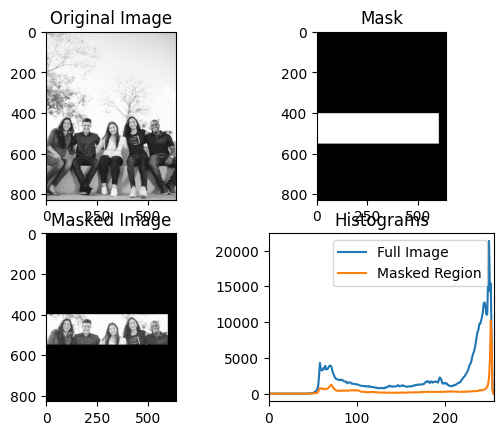

In [ ]:
# Create a mask with the same dimensions as the image, initialized to 0 (black)
mask = np.zeros(img.shape[:2], np.uint8)

# Define a rectangular region in the mask (from row 100 to 400, and column 300 to 650) and set it to 255 (white)
mask[400:550, 0:600] = 255

# Apply the mask to the image using a bitwise AND operation
masked_img = cv.bitwise_and(img, img, mask=mask)

# Calculate histogram of the full image (no mask) and the masked region only
hist_full = cv.calcHist([img], [0], None, [256], [0, 255])  # Histogram of full image
hist_mask = cv.calcHist([img], [0], mask, [256], [0, 255])  # Histogram of masked region only

# Set up subplots to display the images and histograms
plt.subplot(221), plt.imshow(img, 'gray')  # Original image
plt.title("Original Image")

plt.subplot(222), plt.imshow(mask, 'gray')  # Display the mask
plt.title("Mask")

plt.subplot(223), plt.imshow(masked_img, 'gray')  # Display the masked image
plt.title("Masked Image")

# Display histograms: full image histogram and masked region histogram
plt.subplot(224), plt.plot(hist_full, label='Full Image'), plt.plot(hist_mask, label='Masked Region')
plt.xlim([0, 256])  # Set x-axis range for pixel intensities
plt.legend()  # Add a legend to distinguish between histograms
plt.title("Histograms")

# Display all subplots
plt.show()


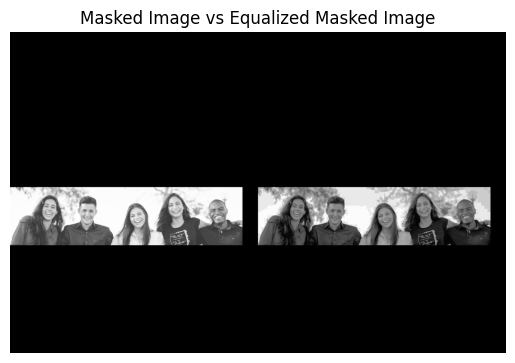

In [ ]:
# Apply histogram equalization to the masked image
equ2 = cv.equalizeHist(masked_img)

# Stack the original masked image and the equalized image side-by-side for comparison
res = np.hstack((masked_img, equ2))  # Combine 'masked_img' and 'equ' horizontally

# Save the resulting stacked image as 'imgKarlMax_Maskres.png'
cv.imwrite('imgKarlMax_Maskres.png', res)

# Display the stacked image
plt.imshow(res, cmap="gray")  # Show the combined image in grayscale
plt.title("Masked Image vs Equalized Masked Image")  # Set title for clarity
plt.axis('off')  # Hide axes for a cleaner display

# Render the image
plt.show()

## CLAHE (Contrast Limited Adaptive Histogram Equalization)


In [ ]:
# Create a CLAHE (Contrast Limited Adaptive Histogram Equalization) object
# clipLimit: sets the threshold for contrast limiting
# tileGridSize: defines the number of tiles in the grid (here, an 8x8 grid)
clahe = cv.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))

# Apply the CLAHE to the grayscale image
cl2 = clahe.apply(img)

# Save the result of CLAHE applied image as 'clahe_4.jpg'
cv.imwrite('clahe_4.jpg', cl2)

True

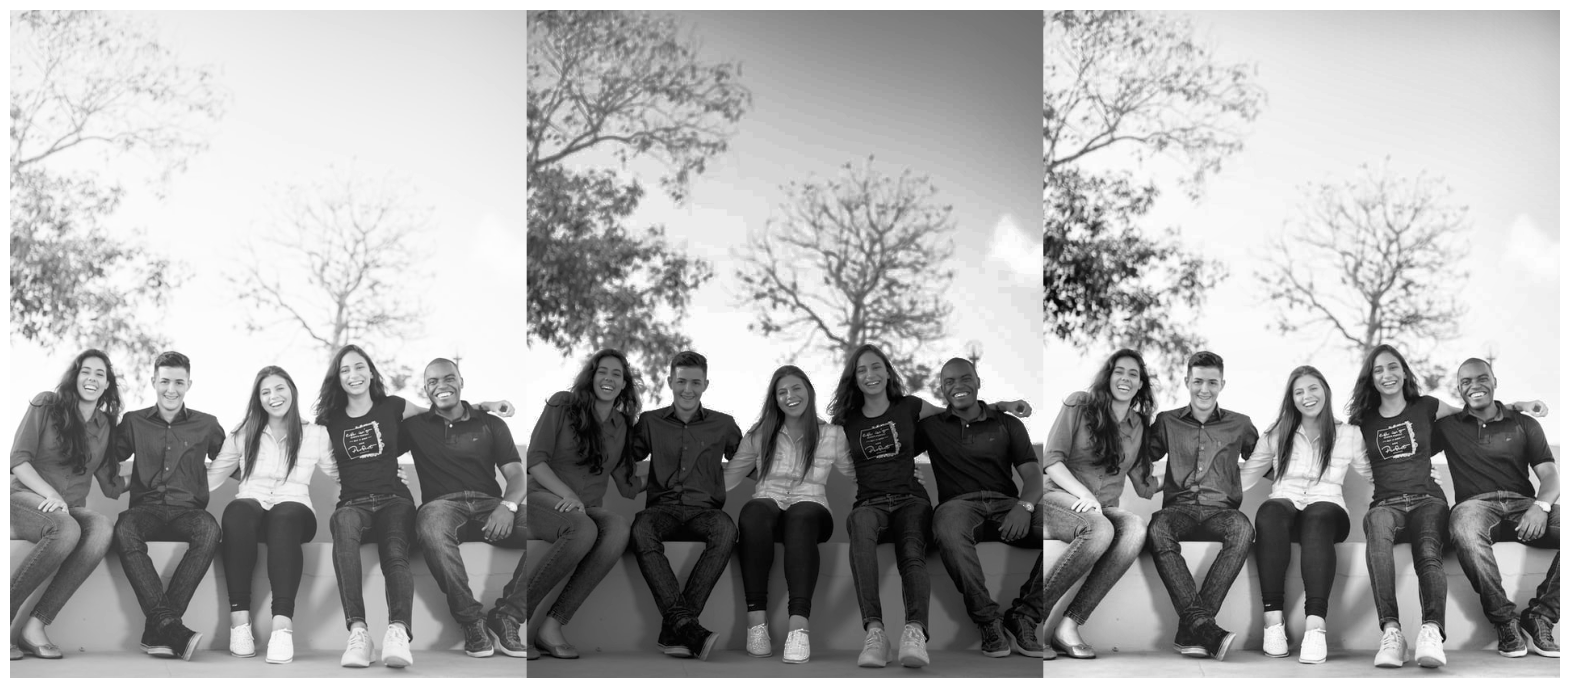

In [ ]:
# Stack the original image, the equalized image, and the CLAHE result side-by-side
res = np.hstack((img, equ, cl2))  # Combine 'img', 'equ', and 'cl1' horizontally

# Set the figure size for the display
plt.figure(figsize=(20, 20))  # Create a figure with a width and height of 20 inches

# Display the stacked image with a grayscale color map
plt.imshow(res, cmap="gray")  # Show the combined image in grayscale
plt.axis('off')  # Turn off axis ticks and labels for a cleaner look

# Render the image
plt.show()  # Display the figure with the stacked images

### **Nhận xét:**
**1. Ảnh Gốc (bên trái):**


- Độ tương phản thấp
-  Chi tiết ở vùng sáng (như bầu trời) bị mất
-  Các chi tiết trên khuôn mặt và quần áo không rõ ràng
-  Thiên về tone sáng


**2. Ảnh sau Histogram Equalization (giữa):**


-  Độ tương phản tăng mạnh
-  Chi tiết rõ nét hơn ở mọi vùng
-  Có thể thấy rõ hơn các nếp gấp trên quần áo
-  Chi tiết khuôn mặt và biểu cảm rõ hơn
-  Tuy nhiên, có dấu hiệu của over-enhancement
-  Một số vùng có thể bị nhiễu


**3. Ảnh sau CLAHE (bên phải):**


-  Cân bằng tốt nhất giữa độ tương phản và chi tiết
-  Giữ được vẻ tự nhiên của ảnh
-  Chi tiết được cải thiện mà không bị quá mức
-  Không có hiện tượng nhiễu rõ rệt
-  Các gradient chuyển tiếp mượt mà hơn